## Settings and imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

DATA_PATH = config["training_data_path"]
MODELS_PATH = config["models_path"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

## Preprocessing

0. Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [4]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [5]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [6]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [7]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [8]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's multiply the indicators by weights (leave inks as they re)/

In [9]:
inDKs_df = divide_by_weights(inDKs_df, ELEMENTS_TO_KEEP, suffix='_i', weights=MULTIPLICATION_WEIGHTS)

6. Normalize with respect to Fe and remove Fe (both indicators and inks).

In [10]:
inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

7. Remove Fe.

In [11]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP_NO_FE)

### Train test split, datasets, dataloaders

In [12]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [13]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(
                                                                                                                X_y_train, 
                                                                                                                X_y_val, 
                                                                                                                X_y_test, 
                                                                                                                ELEMENTS_TO_KEEP_NO_FE)

### Normalization / taking logarithm

In [14]:
X_train = transform_data(X_train, 'logarithm')
y_train = transform_data(y_train, 'logarithm')
X_val = transform_data(X_val, 'logarithm')
y_val = transform_data(y_val, 'logarithm')
X_test = transform_data(X_test, 'logarithm')
y_test = transform_data(y_test, 'logarithm')

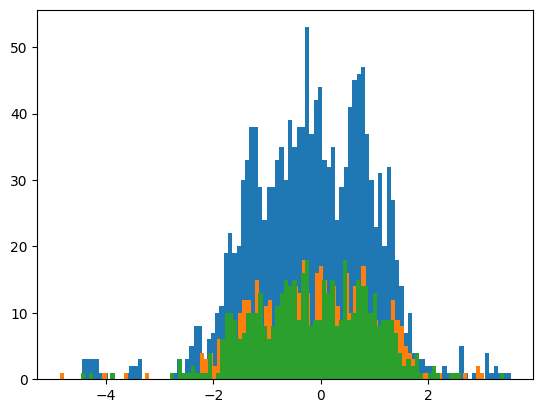

In [15]:
dim = 0
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);

### Converting to tensors

In [16]:
device = get_device()

Using cuda device


In [17]:
X_train = data_to_device(X_train, device)
y_train = data_to_device(y_train, device)
X_val = data_to_device(X_val, device)
y_val = data_to_device(y_val, device)
X_test = data_to_device(X_test, device)
y_test = data_to_device(y_test, device)

### Dataset

In [18]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [19]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Neural network

In [20]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): Dropout(p=0.1, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.1, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.1, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): BatchNorm1d(64, eps=1e-05,

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [21]:
weights = torch.tensor([1/INPUT_SIZE]*INPUT_SIZE).unsqueeze(1).to(device)
loss_fn = CustomLoss(weights=weights)

In [23]:
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

EPOCH 1:
LOSS train 5.7965360959370935 test 5.770679646227733
EPOCH 2:
LOSS train 5.354445362091065 test 4.991284068808498
EPOCH 3:
LOSS train 4.896242904663086 test 4.366634873501268
EPOCH 4:
LOSS train 4.377422714233399 test 3.7137194699551688
EPOCH 5:
LOSS train 3.7877716223398843 test 3.1228466258949066
EPOCH 6:
LOSS train 3.1712968826293944 test 2.651617659023967
EPOCH 7:
LOSS train 2.6084433873494466 test 2.378905079450952
EPOCH 8:
LOSS train 2.130875317255656 test 1.8831205573905423
EPOCH 9:
LOSS train 1.752580499649048 test 1.601061557550507
EPOCH 10:
LOSS train 1.450425378481547 test 1.3309970431059719
EPOCH 11:
LOSS train 1.272012186050415 test 1.2719381236168275
EPOCH 12:
LOSS train 1.0872656583786011 test 1.0038579696991357
EPOCH 13:
LOSS train 0.9794932881991069 test 0.8819030167527467
EPOCH 14:
LOSS train 0.9311046838760376 test 0.8494897998839497
EPOCH 15:
LOSS train 0.8829631090164185 test 0.8083991919715242
EPOCH 16:
LOSS train 0.8758538603782654 test 0.772943792961926

### Loss visualisation

In [22]:
#%matplotlib widget

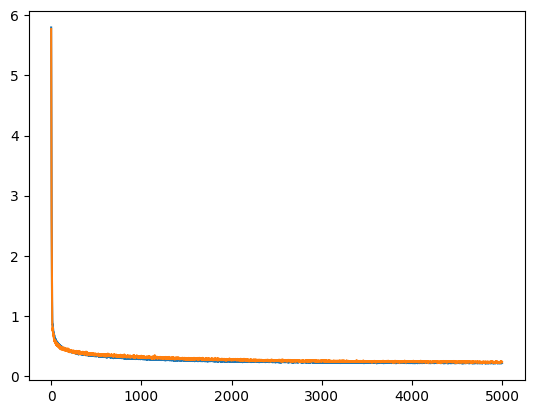

In [24]:
visualise_losses(train_losses, val_losses)

## Loading pretrained model

In [24]:
# model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
# model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_7403/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction on test set

In [25]:
labels, outputs, difference, mean_loss = evaluate_on_test_set(model=model, 
                                                              test_loader=test_loader, 
                                                              loss_fn=loss_fn)

Consecutive inks from test set are in labels tensor (498 examples, 10 elements/coordinates):

In [26]:
labels

tensor([[ -4.3209,  -6.1565,  -9.9935,  ...,  -6.3401,  -5.5264,   9.5189],
        [ -3.4265,  -5.6875,  -9.0043,  ...,  -8.3368,  -3.0887,   9.2628],
        [ -4.5778,  -5.6818, -10.0823,  ...,  -7.9772,  -5.7581,   8.8082],
        ...,
        [ -3.5898,  -5.2295, -10.0223,  ...,  -7.4466,  -4.4181,   9.3459],
        [ -4.0089,  -5.9244, -10.4436,  ...,  -8.8882,  -4.9559,  10.5740],
        [ -3.1474,  -4.6304,  -9.3687,  ...,  -4.7091,  -3.9306,   8.9485]],
       device='cuda:0')

Predictions are in out tensor (498 examples, 10 elements/coordinates):

In [27]:
outputs

tensor([[ -4.6000,  -6.1252, -10.1592,  ...,  -6.5179,  -5.6891,   9.4244],
        [ -3.3944,  -5.6425,  -8.8303,  ...,  -8.4643,  -2.9427,   9.1634],
        [ -4.4889,  -5.4305, -10.0719,  ...,  -7.4884,  -5.7124,   8.9335],
        ...,
        [ -3.4868,  -5.5544,  -9.3153,  ...,  -8.3311,  -4.7794,   9.1016],
        [ -3.9778,  -5.6457, -10.1966,  ...,  -8.5944,  -4.9094,  10.2914],
        [ -3.4865,  -4.6309,  -9.4063,  ...,  -5.1866,  -2.6984,  10.2203]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (labels) and prediction (outputs) are stored in difference tensor (498 examples, 10 elements/coordinates):

In [28]:
#difference

Mean loss:

In [28]:
mean_loss

0.2265207595060987

In [29]:
mean_loss

0.1898058955613748

In [29]:
torch.mean(difference, axis=0)  # 10 elements, new data

tensor([0.2152, 0.2034, 0.4132, 0.1391, 0.2171, 0.2018, 0.2405, 0.2113, 0.1971],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [30]:
torch.mean(difference, axis=0)  # 10 elements, new data

tensor([0.1364, 0.1907, 0.3598, 0.1390, 0.2053, 0.1704, 0.2070, 0.1809, 0.1565,
        0.1520], device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

## Saving the model

In [30]:
MODELS_PATH

'../models/model_regression_logarithm_outer_removed_1_Al_S_Cr_Mn_Co_Cu_Zn_Pb_Fe_Mg_2025_08_26_15_55_18'

In [31]:
save_model(model, MODELS_PATH, HOW_MANY_OUTER_TO_REMOVE, 
                ELEMENTS_TO_KEEP, PREPROCESSING_METHOD)

### Visualisations

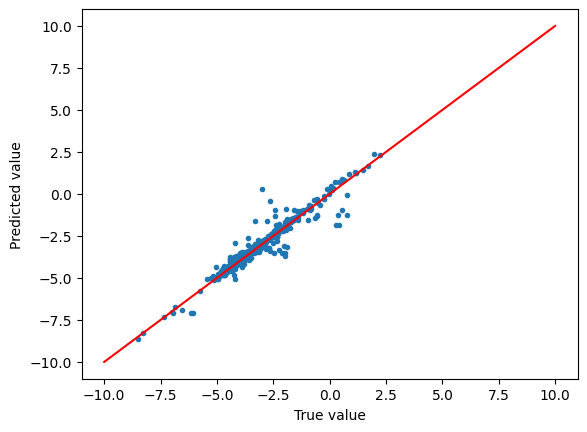

In [41]:
visualise_prediction_against_true(outputs, labels, dimension=0)

## Quality of prediction: closest points

### Creating df with means of classes

In [43]:
mean_df = create_means_df(ELEMENTS_TO_KEEP_NO_FE, y_train.cpu(), train_order, y_val.cpu(), val_order)

### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [46]:
y_test_df, consistency = find_and_compare_closest_class(y_test.cpu(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [35]:
consistency

0.9658634538152611

### Now let's check if it works for the neural network's output.

In [48]:
model.eval()
outputs = model(X_test)

In [50]:
outputs_df, accuracy = find_and_compare_closest_class(outputs.cpu().detach().numpy(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [51]:
accuracy = compute_accuracy(outputs_df)

Accuracy: 86.9%.


In [52]:
precision, recall = compute_precision_and_recall(outputs_df)

Precision: 0.8974025974025973
Recall: 0.8883928571428571


/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:193: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:194: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


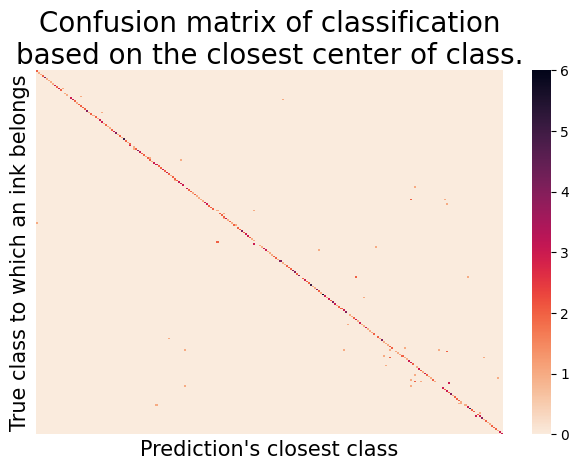

In [53]:
plot_confusion_matrix(true_labels = outputs_df['Real sample_id'], 
                      closest_labels = outputs_df['Closest sample id'], 
                      normalization_in_conf_mat = None, 
                      path_to_save = None)

## Quality of prediction: confidence intervals

In [54]:
model.eval()
outputs = model(X_test)

In [56]:
min_df, max_df, min_max_df = create_min_max_df(y_train.cpu(), 
                                               train_order, 
                                               y_val.cpu(), 
                                               val_order, 
                                               ELEMENTS_TO_KEEP_NO_FE)

In [57]:
lower_bound_df, upper_bound_df = create_mean_plus_sd_df(y_train.cpu(), 
                                                        train_order, 
                                                        y_val.cpu(), 
                                                        val_order, 
                                                        ELEMENTS_TO_KEEP_NO_FE, 
                                                        how_many_sd=2)

In [58]:
min_max_res_list, fraction_1 = is_inside_min_max_interval(outputs, test_order, min_df, max_df)

In [59]:
sd_res_list, fraction_2 = is_inside_mean_plus_minus_sd_interval(outputs, test_order, lower_bound_df, upper_bound_df)

Percentage of points inside min-max interval:

In [60]:
fraction_1

np.float64(0.5662650602409639)

On consecutive coordinates:

In [47]:
np.array(min_max_res_list).mean(0)

array([[0.71285141, 0.75100402, 0.85140562, 0.73293173, 0.76305221,
        0.63855422, 0.70883534, 0.71485944, 0.67670683, 0.73694779]])

Percentage of points inside mean +- 2 standard deviations interval:

In [48]:
fraction_2

np.float64(0.8453815261044176)

On consecutive coordinates:

In [63]:
np.array(sd_res_list).mean(0)

array([[0.65461847, 0.84337349, 0.86144578, 0.61445783, 0.66064257,
        0.58032129, 0.62851406, 0.69277108, 0.72088353]])

### Visualisations of min-max intervals

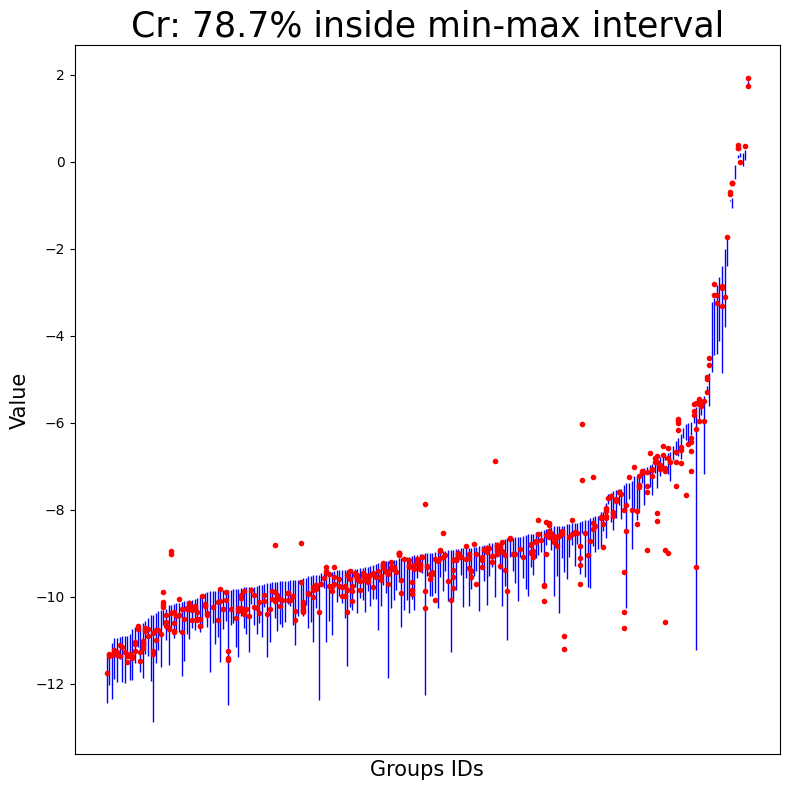

In [65]:
visualise_min_max_intervals(outputs, 
                            test_order, 
                            ELEMENTS_TO_KEEP_NO_FE, 
                            min_max_df, 
                            min_max_res_list, 
                            element_nr=2, 
                            path_to_save=None)

### Visualisations of mean +- 2 * standard deviation intervals

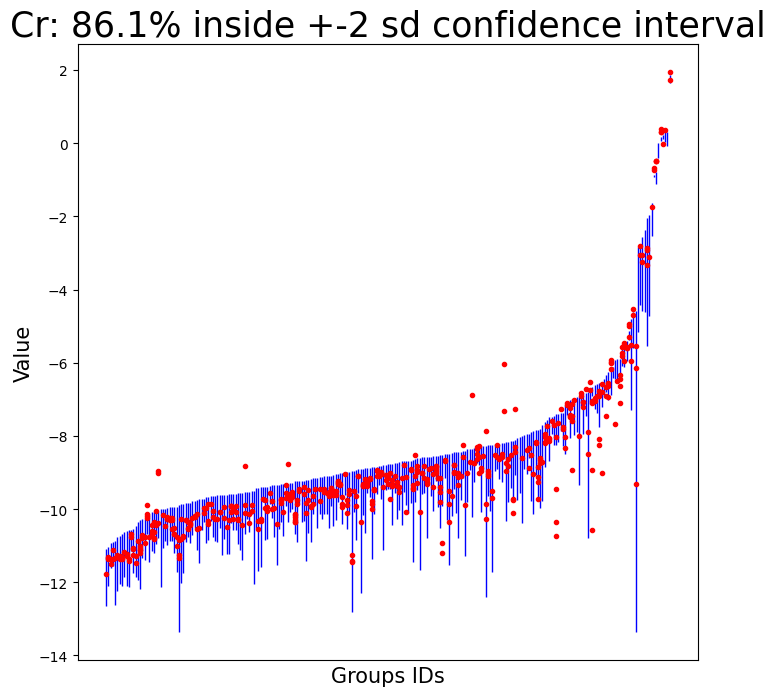

In [66]:
visualise_mean_plus_minus_sd_intervals(outputs, 
                                       test_order, 
                                        ELEMENTS_TO_KEEP_NO_FE, 
                                       lower_bound_df, 
                                       upper_bound_df, 
                                       how_many_sd=2,
                                       sd_res_list=sd_res_list, 
                                       element_nr=2, 
                                       path_to_save=None)